## Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

years = [2019, 2020, 2021, 2022, 2023, 2024]

modes = {}
graphs = {}

base_modes = "../../data/03_modes"

# List all year_month folders
year = "2021"

for speed in ["fast", "medium", "slow"]:
    file_path = f"../../data/04_graphs/{year}/{speed}_graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{speed}_{year}"] = pickle.load(f)
                
        modes[f"{speed}_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/{speed}_emd.parquet")

## Funções

In [2]:
import community as community_louvain

def calculate_hybrid_risk_metric(G, weights=None):
    """
    Calculate the hybrid risk metric R_i for each node in PMFG graph G.
    
    Parameters:
        G (networkx.Graph): PMFG graph with weighted edges (correlations)
        weights (dict): Optional weights for the metrics:
            {
                'degree': float,
                'clustering': float,
                'betweenness': float,
                'edge_weight': float,
                'community': float,
                'kcore': float
            }
            Defaults to equal weights if None.
    
    Returns:
        dict: {node: risk_score (0-1, lower = less risk)}
    """
    # Default equal weights if not provided
    if weights is None:
        weights = {
            'degree': 1/4,
            'clustering': 1/4,
            'betweenness': 1/4,
            'edge_weight': 1/4,
            'community':0,
            'kcore': 0
        }
    
    nodes = list(G.nodes)
    
    # 1. Calculate raw metrics
    
    # Degree
    degree_dict = dict(G.degree())
    
    # Clustering coefficient
    clustering_dict = nx.clustering(G, weight='weight')
    
    # Betweenness centrality
    betweenness_dict = nx.betweenness_centrality(G, weight='weight', normalized=True)
    
    # Average edge weight per node (mean correlation of edges)
    avg_edge_weight = {}
    for node in nodes:
        edges = G.edges(node, data='weight', default=0)
        weights_list = [abs(data) for _, _, data in edges]  # absolute value of correlations
        avg_edge_weight[node] = np.mean(weights_list) if weights_list else 0
    
    # Community detection (Louvain)
    partition = community_louvain.best_partition(G, weight='weight', random_state=0)
    
    # Count unique communities connected to node (including its own)
    community_of_node = {node: partition[node] for node in nodes}
    community_neighbors_count = {}
    for node in nodes:
        neighbors = G.neighbors(node)
        neighbor_communities = set([partition[n] for n in neighbors])
        # Include own community
        neighbor_communities.add(partition[node])
        community_neighbors_count[node] = len(neighbor_communities)
    
    # K-core number
    kcore_dict = nx.core_number(G)
    
    # 2. Normalize metrics (0=lowest risk, 1=highest risk)
    def normalize_dict(d, invert=False):
        vals = np.array(list(d.values()))
        min_val = vals.min()
        max_val = vals.max()
        if max_val - min_val == 0:
            # Avoid division by zero if all values equal
            return {k: 0.0 for k in d.keys()}
        norm = {k: (v - min_val) / (max_val - min_val) for k, v in d.items()}
        if invert:
            norm = {k: 1 - v for k, v in norm.items()}
        return norm
    
    norm_degree = normalize_dict(degree_dict, invert=False)
    norm_clustering = normalize_dict(clustering_dict, invert=False)
    norm_betweenness = normalize_dict(betweenness_dict, invert=False)
    norm_edge_weight = normalize_dict(avg_edge_weight, invert=False)
    norm_community = normalize_dict(community_neighbors_count, invert=True)  # higher community count = lower risk
    norm_kcore = normalize_dict(kcore_dict, invert=False)
    
    # 3. Combine metrics with weights
    risk_scores = {}
    for node in nodes:
        score = (
            weights['degree'] * norm_degree[node] +
            weights['clustering'] * norm_clustering[node] +
            weights['betweenness'] * norm_betweenness[node] +
            weights['edge_weight'] * norm_edge_weight[node] +
            weights['community'] * norm_community[node] +
            weights['kcore'] * norm_kcore[node]
        )
        risk_scores[node] = score
    
    return risk_scores

## Construção do DataFrame com os nós e as métricas de grafos calculadas para cada modo

In [3]:
data = []

for name, G in graphs.items():
    _, speed, year = name.split("_")

    hrm = calculate_hybrid_risk_metric(G)

    for node in G.nodes():
        data.append({
            "node": node,
            "hrm": hrm[node],
            "speed": speed.capitalize(),
            "year": year
        })

df = pd.DataFrame(data)

## Construção dos portfólios Fast, Medium e Slow

Para a construção dos portfólios, dado um nó e sua métrica hrm (CRS da qualificação) para cada um dos modos, avalia-se em qual dos modos a métrica é mais extrema, indicando qual portfólio o ativo deve compor.

In [4]:
df = df.copy()

df["rank"] = (
    df.groupby(["year", "speed"])["hrm"]
      .rank(ascending=False, method="first")
)

df["n_graph"] = (
    df.groupby(["year", "speed"])["node"]
      .transform("count")
)

df["ext_central"] = 1 - (df["rank"] - 1) / (df["n_graph"] - 1)
df["ext_peripheral"] = (df["rank"] - 1) / (df["n_graph"] - 1)

records = []

for _, r in df.iterrows():
    for pos, ext in [("Central", r["ext_central"]),
                     ("Peripheral", r["ext_peripheral"])]:
        records.append({
            "year": r["year"],
            "node": r["node"],
            "speed": r["speed"],
            "position": pos,
            "extremeness": ext
        })

df_choices = pd.DataFrame(records)

df_final = (
    df_choices
    .sort_values("extremeness", ascending=False)
    .groupby(["year", "node"], as_index=False)
    .first()
)

df_final = df_final.query("extremeness >= 0.75")

CF = df_final.query("speed=='Fast' and position=='Central'")["node"]
PF = df_final.query("speed=='Fast' and position=='Peripheral'")["node"]

CM = df_final.query("speed=='Medium' and position=='Central'")["node"]
PM = df_final.query("speed=='Medium' and position=='Peripheral'")["node"]

CS = df_final.query("speed=='Slow' and position=='Central'")["node"]
PS = df_final.query("speed=='Slow' and position=='Peripheral'")["node"]

In [5]:
portfolios = {
    "CF": CF,
    "PF": PF,
    "CM": CM,
    "PM": PM,
    "CS": CS,
    "PS": PS,
}

def common_assets(df1, df2):
    return len(set(df1) & set(df2))

overlap = pd.DataFrame(
    index=portfolios.keys(),
    columns=portfolios.keys(),
    dtype=int
)

for p1, df1 in portfolios.items():
    for p2, df2 in portfolios.items():
        overlap.loc[p1, p2] = common_assets(df1, df2)

overlap

,CF,PF,CM,PM,CS,PS
CF,123.0,0.0,0.0,0.0,0.0,0.0
PF,0.0,89.0,0.0,0.0,0.0,0.0
CM,0.0,0.0,108.0,0.0,0.0,0.0
PM,0.0,0.0,0.0,80.0,0.0,0.0
CS,0.0,0.0,0.0,0.0,103.0,0.0
PS,0.0,0.0,0.0,0.0,0.0,107.0


In [6]:
df["portfolio"] = np.select(
    [
        df["node"].isin(CF),
        df["node"].isin(PF),
        df["node"].isin(CM),
        df["node"].isin(PM),
        df["node"].isin(CS),
        df["node"].isin(PS),
    ],
    [
        "central_fast",
        "peripheral_fast",
        "central_medium",
        "peripheral_medium",
        "central_slow",
        "peripheral_slow",
    ],
    default="unclassified"
)

In [7]:
plot_df = pd.DataFrame(df.groupby("node")["portfolio"].first()).reset_index()

plot_df["speed"] = np.where(
    plot_df["portfolio"].str.contains("fast"),
    "Fast",
    np.where(
        plot_df["portfolio"].str.contains("medium"),
        "Medium",
        "Slow"
    )
)

plot_df = plot_df.merge(
    right=df[["node", "speed", "hrm", "ext_central"]],
    how="left",
    on=["node", "speed"]
)

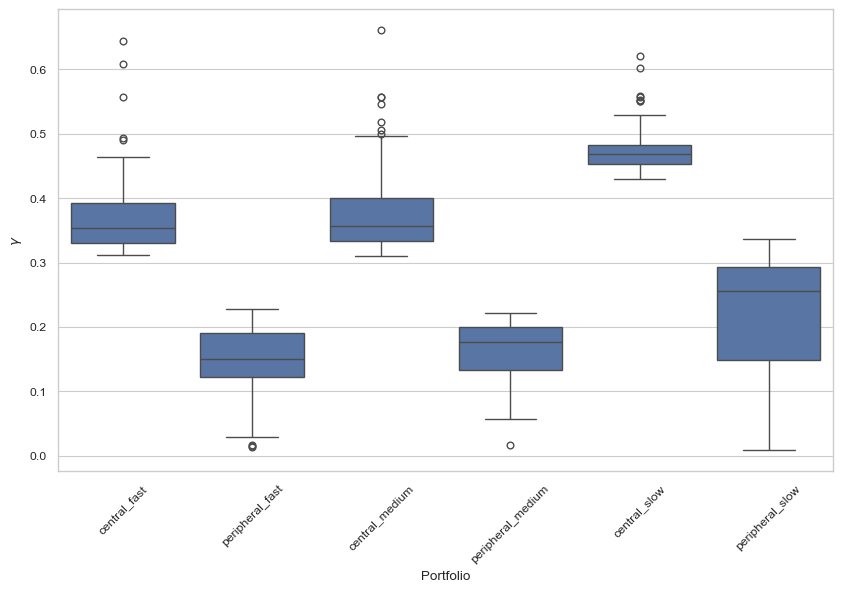

In [8]:
sns.set_theme(style="whitegrid", context="paper")

order = [
    "central_fast", "peripheral_fast",
    "central_medium", "peripheral_medium",
    "central_slow", "peripheral_slow",
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=plot_df,
    x="portfolio",
    y="hrm",
    order=order
)

plt.xticks(rotation=45)
plt.xlabel("Portfolio")
plt.ylabel("$\gamma$")
plt.show()

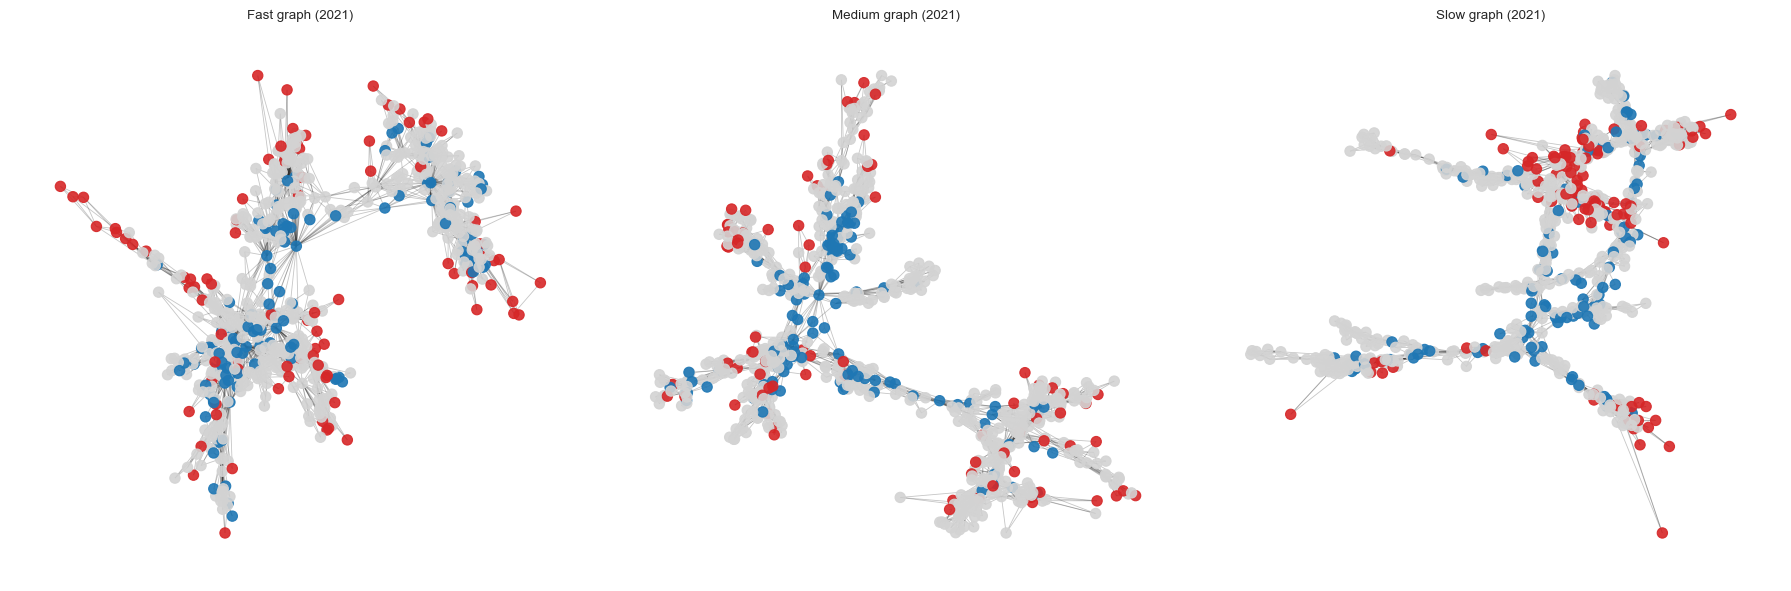

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

modes = ["fast", "medium", "slow"]

COLOR = {
    "fast": {
        "central_fast": "#1f77b4",
        "peripheral_fast": "#d62728",
    },
    "medium": {
        "central_medium": "#1f77b4",
        "peripheral_medium": "#d62728",
    },
    "slow": {
        "central_slow": "#1f77b4",
        "peripheral_slow": "#d62728",
    }
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, mode in zip(axes, modes):

    G = graphs[f"graph_{mode}_{year}"]

    # lookup node -> portfolio daquele modo
    portfolio_map = (
        plot_df
        .loc[plot_df["portfolio"].str.contains(mode), ["node", "portfolio"]]
        .drop_duplicates()
        .set_index("node")["portfolio"]
        .to_dict()
    )

    node_colors = []
    for node in G.nodes():
        portfolio = portfolio_map.get(node)
        if portfolio in COLOR[mode]:
            node_colors.append(COLOR[mode][portfolio])
        else:
            node_colors.append("lightgray")

    # layout fixo por modo (reprodutível)
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=55,
        alpha=0.9,
        ax=ax
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.25,
        width=0.6,
        ax=ax
    )

    ax.set_title(f"{mode.capitalize()} graph (2021)")
    ax.axis("off")

plt.tight_layout()
plt.show()

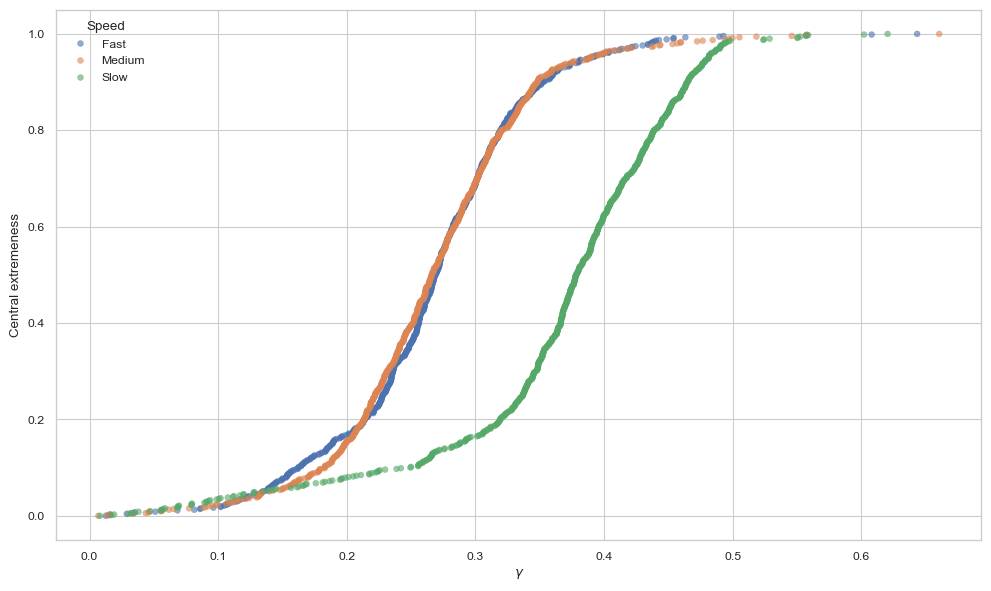

In [10]:
sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="hrm",
    y="ext_central",
    hue="speed",
    alpha=0.6,
    s=18,
    edgecolor=None
)

plt.ylabel("Central extremeness")
plt.xlabel(r"$\gamma$")

plt.legend(
    title="Speed",
    frameon=False,
    loc="best"
)

plt.tight_layout()
plt.show()

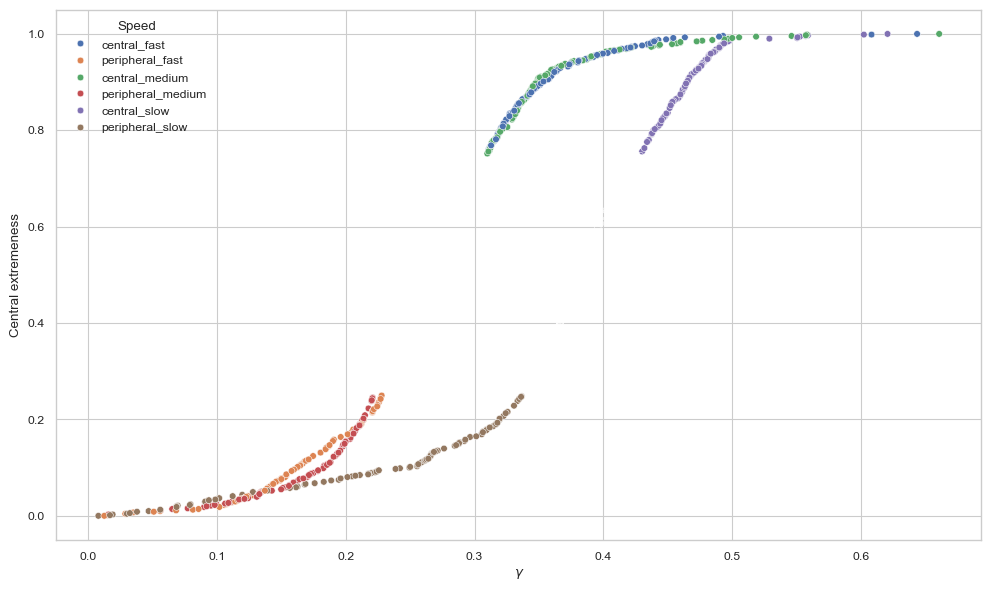

In [11]:
sns.set_theme(style="whitegrid", context="paper")

order = [
    "central_fast", "peripheral_fast",
    "central_medium", "peripheral_medium",
    "central_slow", "peripheral_slow",
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="hrm",
    y="ext_central",
    hue="portfolio",
    hue_order=order
)

plt.ylabel("Central extremeness")
plt.xlabel(r"$\gamma$")

plt.legend(
    title="Speed",
    frameon=False,
    loc="best"
)

plt.tight_layout()
plt.show()

Verificação de que os portfólios não compartilham ativos

In [12]:
from itertools import combinations

portfolios = [CF, PF, CM, PM, CS, PS]

for portfolio in portfolios:
    print(f"{len(portfolio)}")

# for a, b in combinations(portfolios, 2):
#     assert len(set(a) & set(b)) == 0

123
89
108
80
103
107


In [13]:
returns_prev = pd.read_parquet(
    f"../../data/02_clean/returns_{year}.parquet"
)

central_fast_portfolio = returns_prev[CF]
central_medium_portfolio = returns_prev[CM]
central_slow_portfolio = returns_prev[CS]

peripheral_fast_portfolio = returns_prev[PF]
peripheral_medium_portfolio = returns_prev[PM]
peripheral_slow_portfolio = returns_prev[PS]

Salvando arquivo com os ativos

In [14]:
def get_portfolio_info(
        portfolio
):
    stock_info = pd.read_parquet("../../data/01_raw/screener_result.parquet")
    portfolio = portfolio.to_frame().rename(columns={"node":"Ticker"})
    return portfolio.merge(
        stock_info, on="Ticker", how="left"
    )

In [15]:
portfolios = {"Central Fast": CF,
              "Peripheral Fast": PF,
              "Central Medium": CM,
              "Peripheral Medium": PM,
              "Central Slow": CS,
              "Peripheral Slow": PS}
portfolio_metadata = {}

for portfolio_key, portfolio_value in portfolios.items():
    portfolio_metadata[portfolio_key] = get_portfolio_info(portfolio_value)

for key in portfolio_metadata.keys():
    key_path = key.lower().replace(" ", "_")
    save_path = f"../../data/07_portfolios_metadata/{key_path}_metadata_{year}.csv"
    portfolio_metadata[key].to_csv(save_path, index=False)

Cálculos dos retornos

In [16]:
central_fast_monthly_returns = (
    central_fast_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

peripheral_fast_monthly_returns = (
    peripheral_fast_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

central_medium_monthly_returns = (
    central_medium_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

peripheral_medium_monthly_returns = (
    peripheral_medium_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

central_slow_monthly_returns = (
    central_slow_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

peripheral_slow_monthly_returns = (
    peripheral_slow_portfolio
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
    .mean(axis=1)
)

In [17]:
central_fast_weekly_returns = central_fast_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)
peripheral_fast_weekly_returns = peripheral_fast_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)

central_medium_weekly_returns = central_medium_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)
peripheral_medium_weekly_returns = peripheral_medium_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)

central_slow_weekly_returns = central_slow_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)
peripheral_slow_weekly_returns = peripheral_slow_portfolio.resample("W-FRI").apply(lambda x: (1 + x).prod() - 1).mean(axis=1)

In [18]:
# FAST
central_fast_daily_returns = central_fast_portfolio.mean(axis=1)
peripheral_fast_daily_returns = peripheral_fast_portfolio.mean(axis=1)

# MEDIUM
central_medium_daily_returns = central_medium_portfolio.mean(axis=1)
peripheral_medium_daily_returns = peripheral_medium_portfolio.mean(axis=1)

# SLOW
central_slow_daily_returns = central_slow_portfolio.mean(axis=1)
peripheral_slow_daily_returns = peripheral_slow_portfolio.mean(axis=1)

## Lead-lag

In [19]:
def autocorrelation_matrix(X, lag):
    X_t = X.iloc[lag:]
    X_tk = X.shift(lag).iloc[lag:]

    mu = X.mean().values

    Xc_t = X_t.values - mu
    Xc_tk = X_tk.values - mu

    Sigma_k = (Xc_tk.T @ Xc_t) / len(Xc_t)

    var = X.var(ddof=0).values
    D_inv_sqrt = np.diag(1 / np.sqrt(var))

    return D_inv_sqrt @ Sigma_k @ D_inv_sqrt


def plot_antisymmetric_autocorr(
    returns_list,
    column_names,
    labels,
    lags=(1, 2, 3, 4),
    figsize=(12, 8),
    cmap="Blues",
    title_prefix="Y",
    annot=False,
    diff=True
):
    X = pd.concat(returns_list, axis=1)
    X.columns = column_names

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    if len(lags) == 1:
        axes = [axes]

    for ax, lag in zip(axes, lags):
        T = autocorrelation_matrix(X, lag)

        if diff:
            A = pd.DataFrame(
                T - T.T,
                index=labels,
                columns=labels
            )
            title = f"{title_prefix}({lag}) - {title_prefix}'({lag})"
        else:
            A = pd.DataFrame(
                T,
                index=labels,
                columns=labels
            )
            title = f"{title_prefix}({lag})"

        sns.heatmap(A, ax=ax, cmap=cmap, center=0, annot=annot)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [20]:
R1 = central_fast_weekly_returns      # FAST central
R2 = peripheral_fast_weekly_returns   # FAST peripheral
R3 = central_medium_weekly_returns
R4 = peripheral_medium_weekly_returns
R5 = central_slow_weekly_returns    # SLOW central
R6 = peripheral_slow_weekly_returns  # SLOW peripheral

### Fast - Slow

#### Diferença

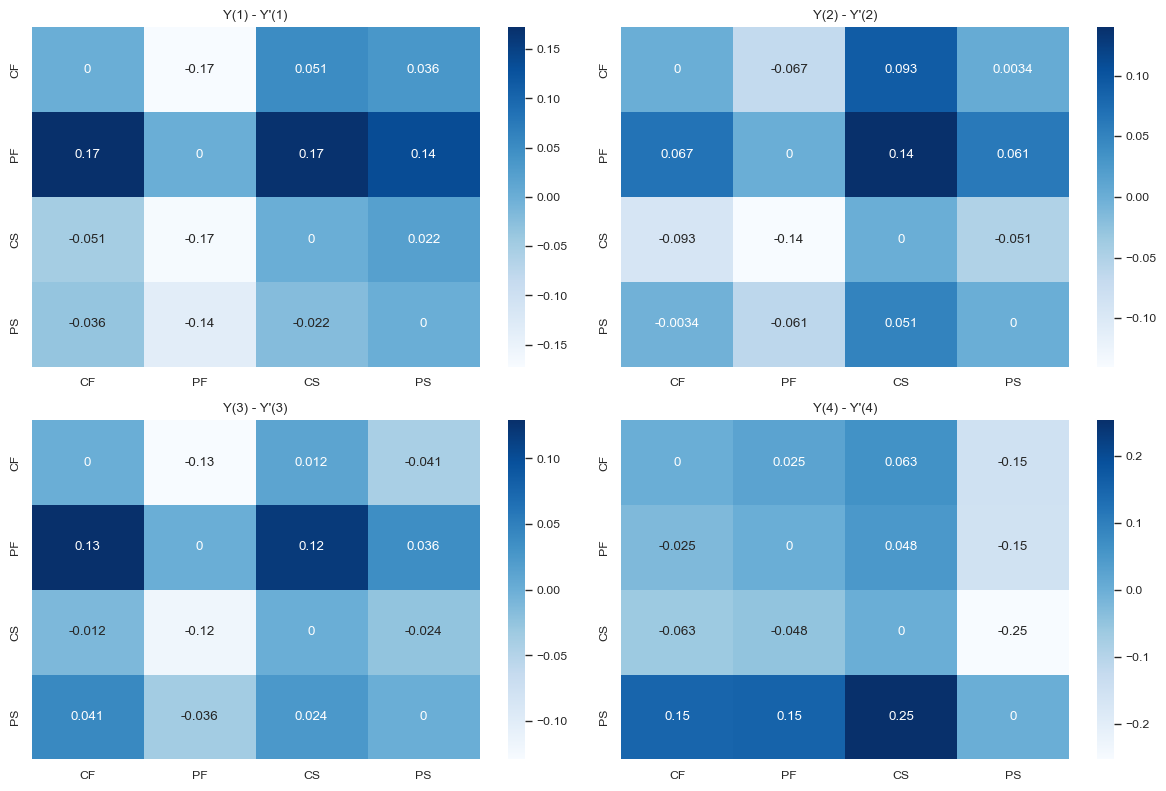

In [21]:
plot_antisymmetric_autocorr(
    returns_list=[R1, R2, R5, R6],
    column_names=["CentralFast", "PeripheralFast",
                  "CentralSlow", "PeripheralSlow"],
    labels=["CF", "PF", "CS", "PS"],
    annot=True
)

In [22]:
lag_list = [1, 2, 3, 4]
matrix = []

for lag in lag_list:
    X = pd.concat([R1, R2, R3, R4, R5, R6], axis=1)
    X.columns = ["CentralFast", "PeripheralFast",
                 "CentralMedium", "PeripheralMedium",
                 "CentralSlow", "PeripheralSlow"]

    acm = autocorrelation_matrix(X, lag)
    lag_matrix = (acm - acm.T)

    matrix.append(np.hstack([lag_matrix[0, 1:], lag_matrix[1, 2:]]))

leadlags = ["cfpf", "cfcm", "cfpm", "cfcs", "cfps", "pfcm", "pfpm", "pfcs", "pfps"]
cols = [f"{leadlag}{i}" for i in range(1, 5) for leadlag in leadlags]

leadlag_df = pd.DataFrame([np.hstack(matrix)], columns=cols, index=[year])
leadlag_df.to_csv(f"../../data/08_lead_lag/leadlag_df_{year}.csv")

### Fast - Medium

#### Diferença

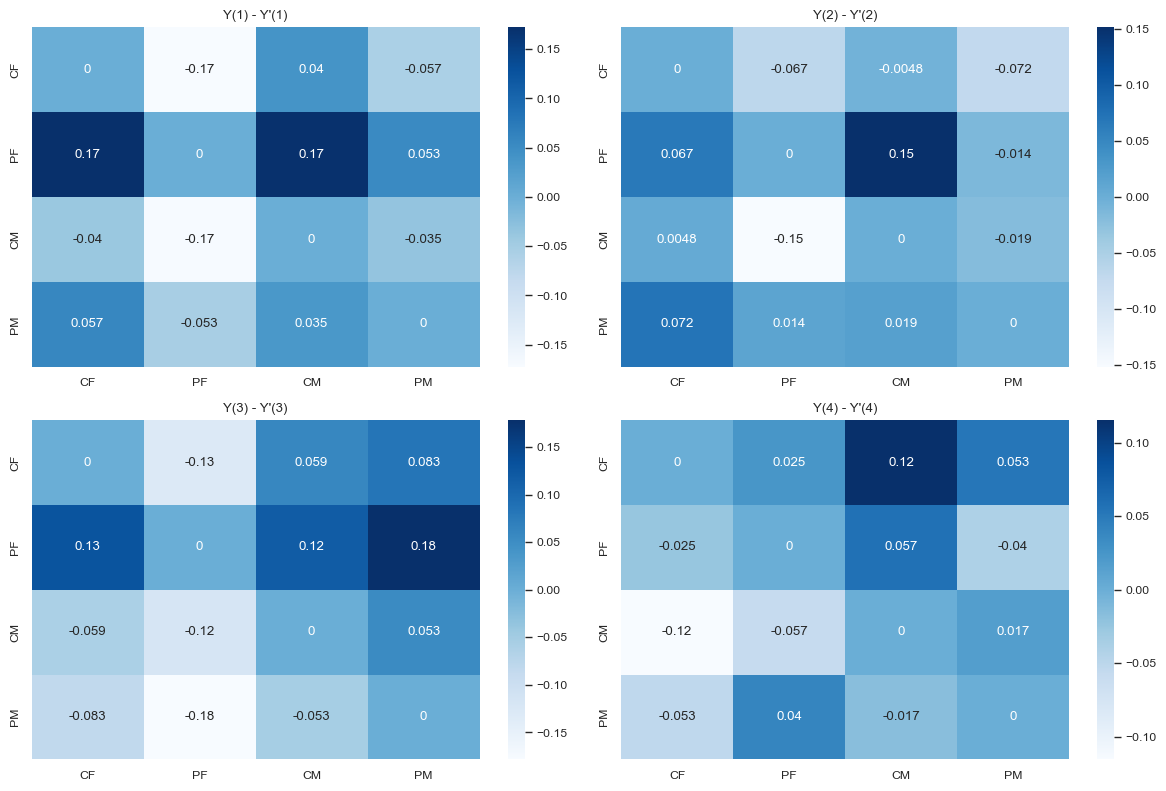

In [23]:
plot_antisymmetric_autocorr(
    returns_list=[R1, R2, R3, R4],
    column_names=["CentralFast", "PeripheralFast",
                  "CentralMedium", "PeripheralMedium"],
    labels=["CF", "PF", "CM", "PM"],
    annot=True
)

### Medium - Slow

#### Diferença

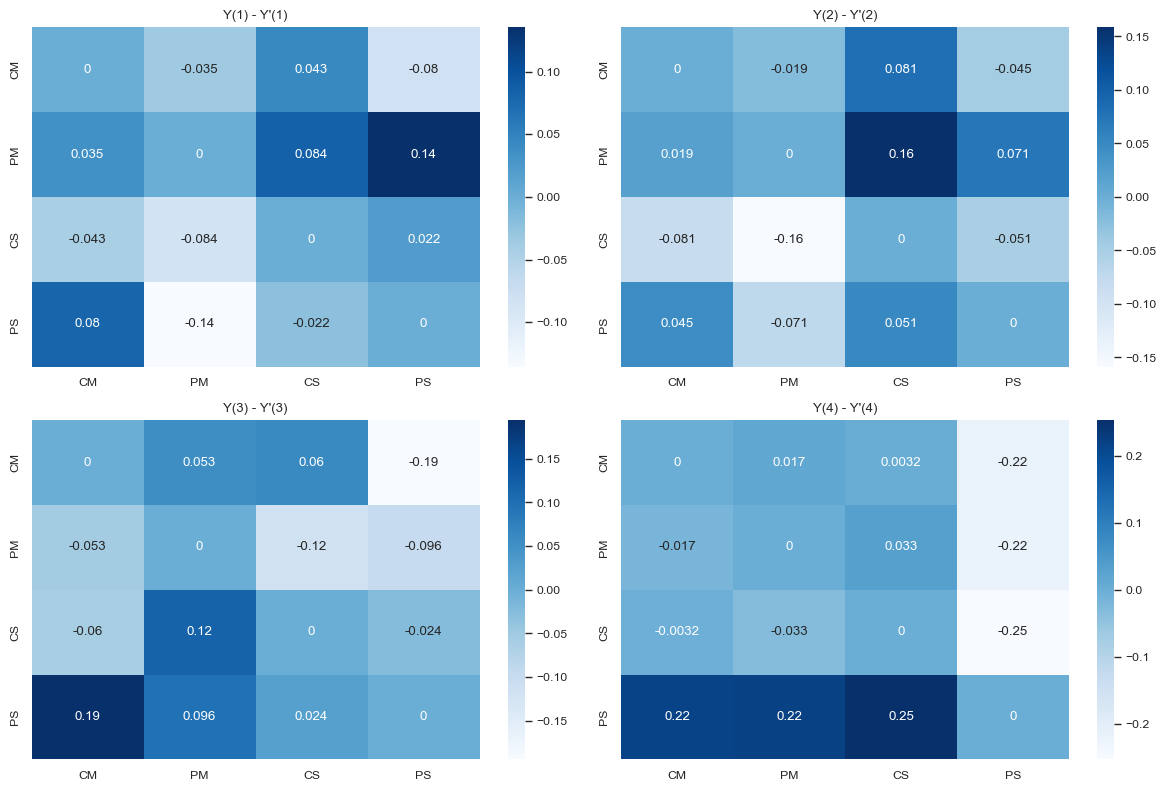

In [24]:
plot_antisymmetric_autocorr(
    returns_list=[R3, R4, R5, R6],
    column_names=["CentralMedium", "PeripheralMedium",
                  "CentralSlow", "PeripheralSlow"],
    labels=["CM", "PM", "CS", "PS"],
    annot=True
)

## Market Cap

In [25]:
df_mcap = pd.read_parquet("../../data/05_metrics/graph_metrics_df.parquet")
df_mcap["mcap_bin"] = (
    df_mcap.groupby("year_month_dt")["Market Cap"]
      .transform(lambda x: pd.qcut(
          x, q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"]
      ))
)

df_agg = df.merge(right=df_mcap[(df_mcap["year_month"]==f"{year}_12")
        & (df_mcap["speed"]=="Fast")][["node", "mcap_bin"]],
         how="inner",
         on=["node"])

# retornos semanais dos portfólios
R1 = returns_prev[list(df_agg[df_agg["mcap_bin"]=="Small"]["node"])].mean(axis=1)
R2 = returns_prev[list(df_agg[df_agg["mcap_bin"]=="Mid-Small"]["node"])].mean(axis=1)
R3 = returns_prev[list(df_agg[df_agg["mcap_bin"]=="Mid-Large"]["node"])].mean(axis=1)
R4 = returns_prev[list(df_agg[df_agg["mcap_bin"]=="Large"]["node"])].mean(axis=1)

lag_list = [1, 2, 3, 4]
matrix = []

for lag in lag_list:
    X = pd.concat([R1, R2, R3, R4], axis=1)
    X.columns = ["Small", "Mid-Small",
                  "Mid-Large", "Large"]

    acm = autocorrelation_matrix(X, lag)
    lag_matrix = (acm - acm.T)

    matrix.append(np.hstack([lag_matrix[0, 1:], lag_matrix[1, 2:]]))

leadlags = ["sms", "sml", "sl", "msml", "msl"]
cols = [f"{leadlag}{i}" for i in range(1, 5) for leadlag in leadlags]

leadlag_df = pd.DataFrame([np.hstack(matrix)], columns=cols, index=[year])
leadlag_df.to_csv(f"../../data/08_lead_lag/marketcap_leadlag_df_{year}.csv")

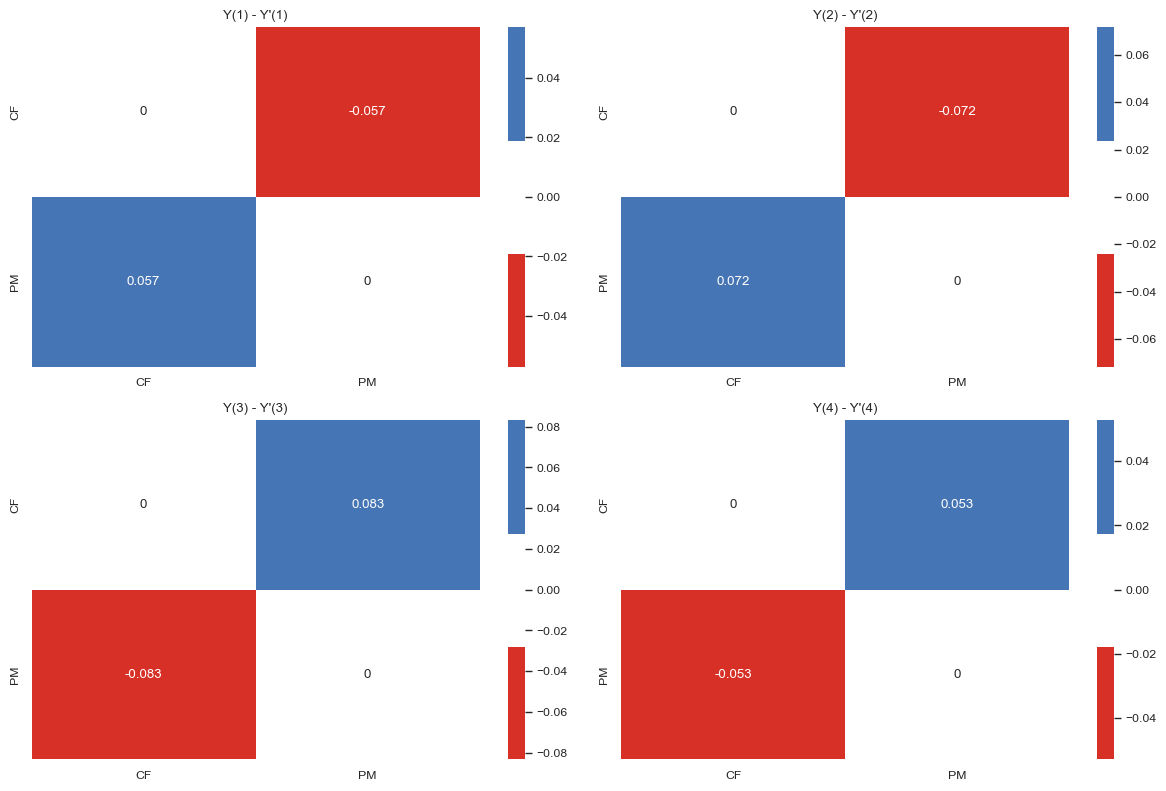

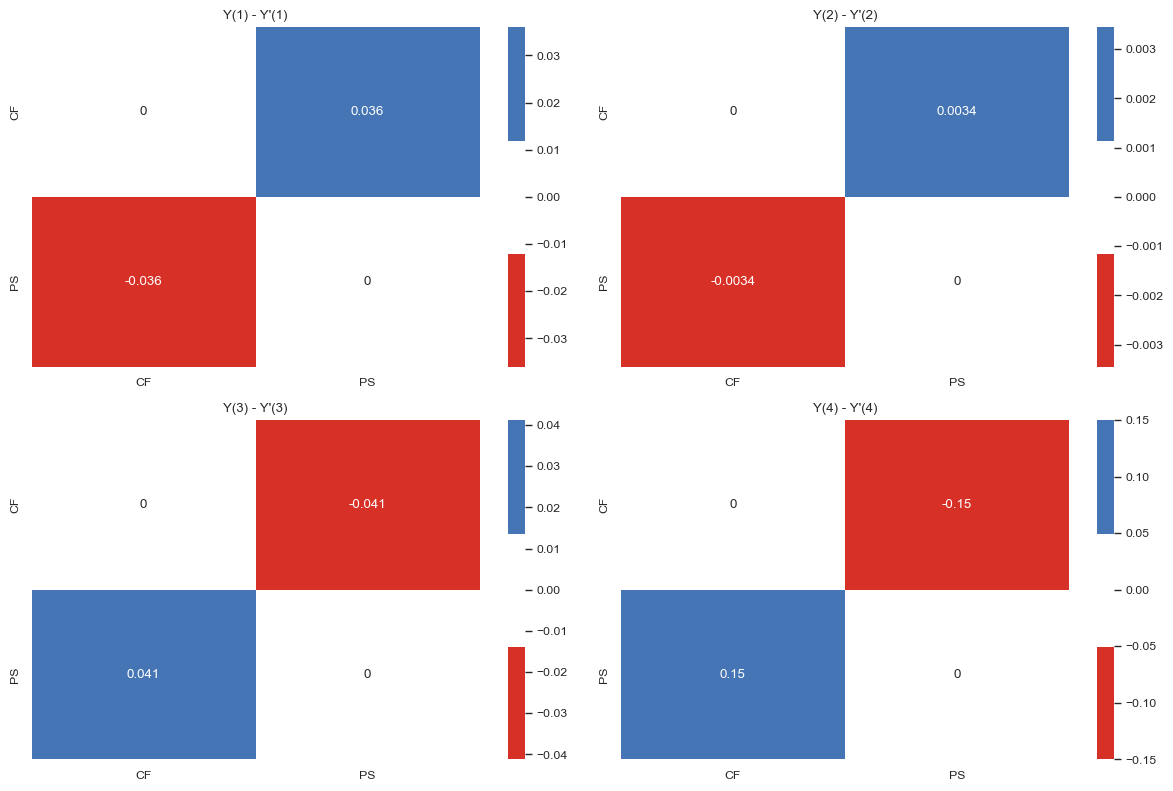

In [26]:
R1 = central_fast_weekly_returns      # FAST central
R2 = peripheral_fast_weekly_returns   # FAST peripheral
R3 = central_medium_weekly_returns
R4 = peripheral_medium_weekly_returns
R5 = central_slow_weekly_returns    # SLOW central
R6 = peripheral_slow_weekly_returns  # SLOW peripheral

from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "#d73027",  # vermelho suave
    "white",
    "#4575b4"   # azul suave
])

plot_antisymmetric_autocorr(
    returns_list=[R1, R4],
    column_names=["CentralFast", "PeripheralMedium"],
    labels=["CF", "PM"],
    annot=True,
    cmap=cmap
)

plot_antisymmetric_autocorr(
    returns_list=[R1, R6],
    column_names=["CentralFast", "PeripheralSlow"],
    labels=["CF", "PS"],
    annot=True,
    cmap=cmap
)